
Проверка гипотезы о нормальном распределении N(0,1)

Объём выборки n=10

Истинное распределение: N(0,1)
  Реализация  1: KS=принимается AD=принимается Chi2=принимается
  Реализация  2: KS=отвергается AD=принимается Chi2=отвергается
  Реализация  3: KS=принимается AD=принимается Chi2=принимается
  Реализация  4: KS=принимается AD=принимается Chi2=принимается
  Реализация  5: KS=принимается AD=принимается Chi2=принимается
  Реализация  6: KS=принимается AD=принимается Chi2=принимается
  Реализация  7: KS=принимается AD=принимается Chi2=принимается
  Реализация  8: KS=принимается AD=принимается Chi2=принимается
  Реализация  9: KS=принимается AD=принимается Chi2=принимается
  Реализация 10: KS=принимается AD=принимается Chi2=принимается


Истинное распределение: N(0,1) + noise
  Реализация  1: KS=принимается AD=принимается Chi2=принимается
  Реализация  2: KS=принимается AD=принимается Chi2=принимается
  Реализация  3: KS=принимается AD=принимается Chi2=принимается
  Реализация  4: KS=пр

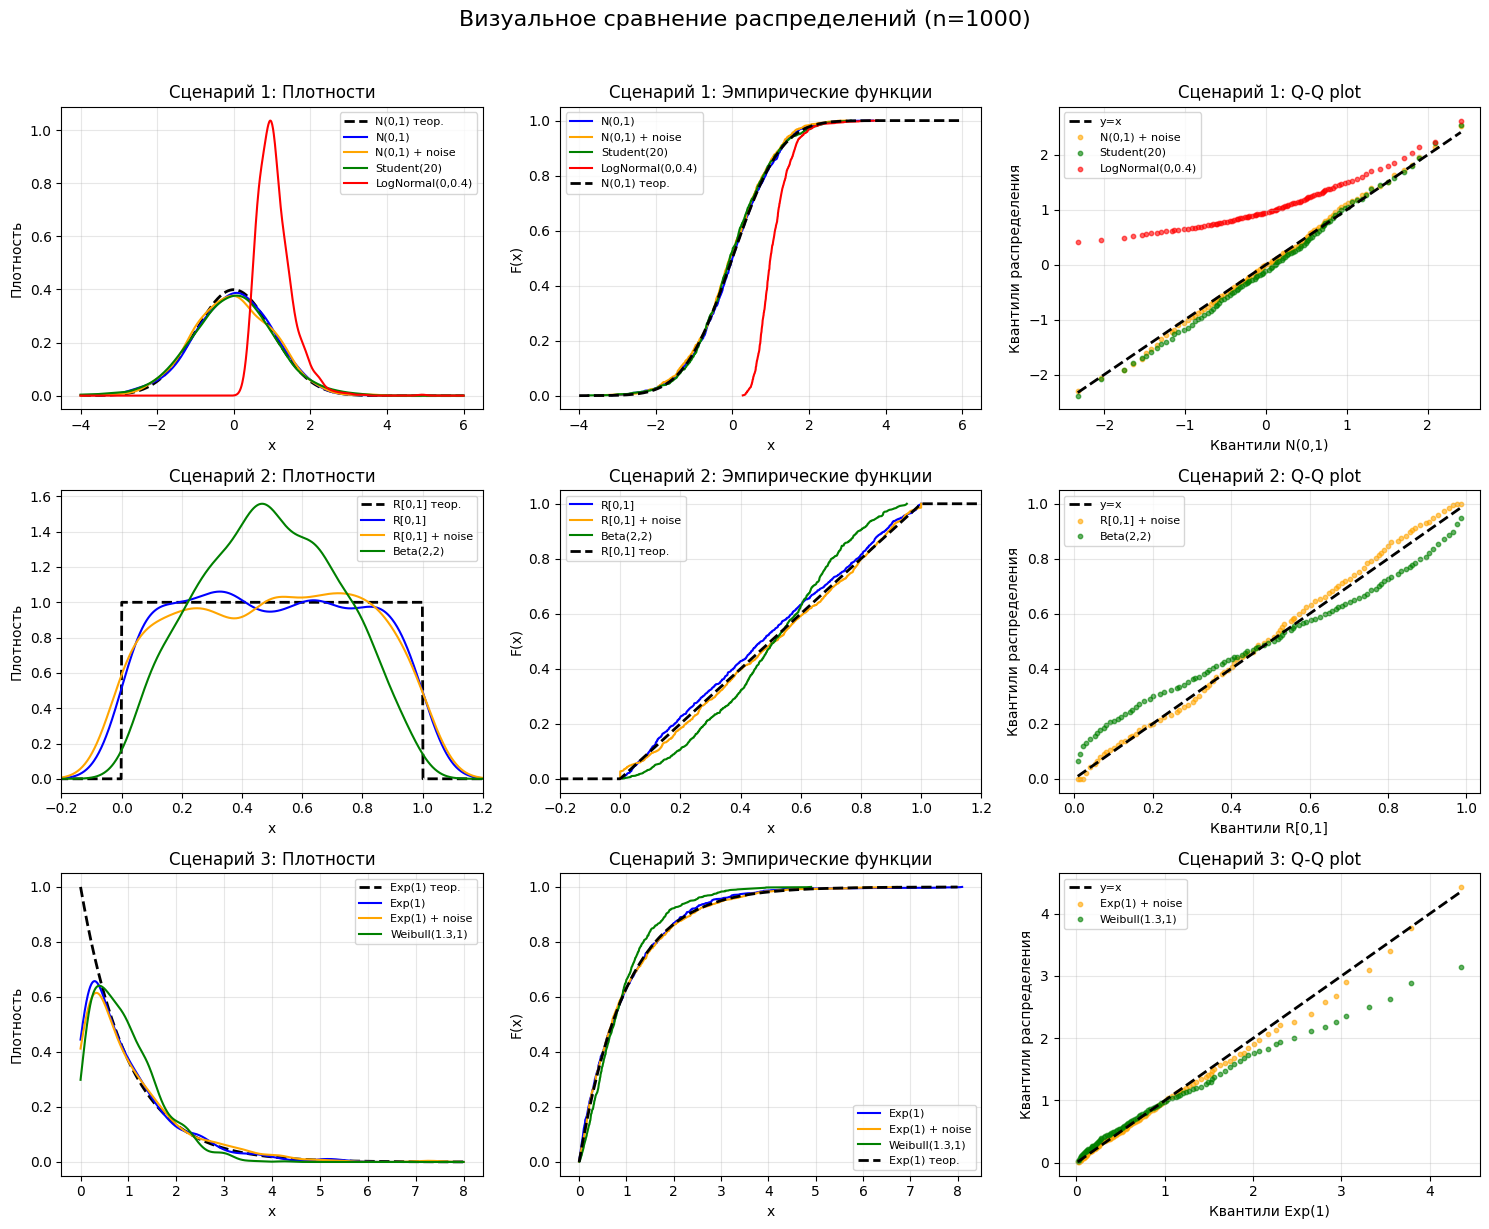

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Функция для критерия Хи-квадрат Пирсона
def chi_square_test(data, dist_name, dist_params):
    n = len(data)
    if n > 200:
        k = int(4 * (n-1) ** (2/5))
    else:
        k = int(np.ceil(1 + np.log2(n)))

    if dist_name == 'norm':
        a, b = -4, 4
    elif dist_name == 'uniform':
        a, b = 0, 1
    elif dist_name == 'expon':
        a, b = 0, 8

    edges = np.linspace(a, b, k + 1)
    edges[0] = -np.inf
    edges[-1] = np.inf

    observed, _ = np.histogram(data, bins=edges)

    if dist_name == 'norm':
        loc, scale = dist_params
        cdf_at_edges = stats.norm.cdf(edges, loc=loc, scale=scale)
    elif dist_name == 'uniform':
        loc, scale = dist_params
        cdf_at_edges = stats.uniform.cdf(edges, loc=loc, scale=scale)
    elif dist_name == 'expon':
        loc, scale = dist_params
        cdf_at_edges = stats.expon.cdf(edges, loc=loc, scale=scale)

    expected_probs = np.diff(cdf_at_edges)
    expected = n * expected_probs

    valid_bins = expected >= 1
    if np.sum(valid_bins) < 2:
        return 1.0

    observed_valid = observed[valid_bins]
    expected_valid = expected[valid_bins]

    T = np.sum((observed_valid - expected_valid)**2 / expected_valid)
    df = len(observed_valid) - 1
    p_value = 1 - stats.chi2.cdf(T, df)
    return p_value

# Функция для критерия Колмогорова-Смирнова
def ks_test(data, dist_name, dist_params):
    if dist_name == 'norm':
        loc, scale = dist_params
        return stats.kstest(data, 'norm', args=(loc, scale))[1]
    elif dist_name == 'uniform':
        loc, scale = dist_params
        return stats.kstest(data, 'uniform', args=(loc, scale))[1]
    elif dist_name == 'expon':
        loc, scale = dist_params
        return stats.kstest(data, 'expon', args=(loc, scale))[1]

# Функция для критерия Андерсона-Дарлинга
def anderson_test(data, dist_name, dist_params):
    if dist_name == 'norm':
        result = stats.anderson(data, dist='norm')
        crit_value = result.critical_values[2]
        return result.statistic > crit_value
    elif dist_name == 'uniform':
        n = len(data)
        data_sorted = np.sort(data)
        epsilon = 1e-10
        data_sorted = np.clip(data_sorted, epsilon, 1 - epsilon)
        i = np.arange(1, n + 1)
        term1 = ((2*i - 1) / (2*n)) * np.log(data_sorted)
        term2 = (1 - (2*i - 1) / (2*n)) * np.log(1 - data_sorted)
        ad_stat = -n - 2 * np.sum(term1 + term2)
        crit_value = 2.492
        return ad_stat > crit_value
    elif dist_name == 'expon':
        loc, scale = dist_params
        data_adj = data - loc
        result = stats.anderson(data_adj, dist='expon')
        crit_value = result.critical_values[2]
        return result.statistic > crit_value

# Генерация данных
def generate_data(dist_name, size, noise_level=0.1):
    if dist_name == 'N(0,1)':
        return np.random.normal(0, 1, size)
    elif dist_name == 'N(0,1) + noise':
        clean_data = np.random.normal(0, 1, size)
        noise = np.random.uniform(-noise_level, noise_level, size)
        return clean_data + noise
    elif dist_name == 'Student(20)':
        return np.random.standard_t(20, size)
    elif dist_name == 'LogNormal(0,0.4)':
        return np.random.lognormal(0, 0.4, size)
    elif dist_name == 'R[0,1]':
        return np.random.uniform(0, 1, size)
    elif dist_name == 'R[0,1] + noise':
        clean_data = np.random.uniform(0, 1, size)
        noise = np.random.uniform(-noise_level, noise_level, size)
        return np.clip(clean_data + noise, 0, 1)
    elif dist_name == 'Beta(2,2)':
        return np.random.beta(2, 2, size)
    elif dist_name == 'Exp(1)':
        return np.random.exponential(1, size)
    elif dist_name == 'Exp(1) + noise':
        clean_data = np.random.exponential(1, size)
        noise = np.random.normal(0, noise_level/2, size)
        return np.abs(clean_data + noise)
    elif dist_name == 'Weibull(1.3,1)':
        return stats.weibull_min.rvs(1.3, scale=1, size=size)

# Функция для запуска всех тестов
def run_all_tests(data, test_dist_name, test_dist_params, alpha=0.05):
    results = {}
    ks_p = ks_test(data, test_dist_name, test_dist_params)
    results['KS'] = ks_p < alpha
    results['AD'] = anderson_test(data, test_dist_name, test_dist_params)
    chi2_p = chi_square_test(data, test_dist_name, test_dist_params)
    results['Chi2'] = chi2_p < alpha
    return results

# Основной анализ
np.random.seed(42)
sample_sizes = [10, 50, 150, 500, 1000, 5000]
n_simulations = 10

def analyze_scenario(scenario_name, true_dists, test_dist_name, test_dist_params):
    print(f"\n{'='*80}")
    print(f"{scenario_name}")
    print(f"{'='*80}")
    for n in sample_sizes:
        print(f"\nОбъём выборки n={n}")
        for true_dist in true_dists:
            print(f"\nИстинное распределение: {true_dist}")
            for sim in range(n_simulations):
                data = generate_data(true_dist, n)
                decisions = run_all_tests(data, test_dist_name, test_dist_params)
                print(f"  Реализация {sim+1:2d}: KS={'отвергается' if decisions['KS'] else 'принимается'} AD={'отвергается' if decisions['AD'] else 'принимается'} Chi2={'отвергается' if decisions['Chi2'] else 'принимается'}")
            print()

# Запуск анализа для трёх сценариев

scenario1_dists = ['N(0,1)', 'N(0,1) + noise', 'Student(20)', 'LogNormal(0,0.4)']
analyze_scenario("Проверка гипотезы о нормальном распределении N(0,1)", scenario1_dists, 'norm', (0, 1))

scenario2_dists = ['R[0,1]', 'R[0,1] + noise', 'Beta(2,2)']
analyze_scenario("Проверка гипотезы о равномерном распределении R[0,1]", scenario2_dists, 'uniform', (0, 1))

scenario3_dists = ['Exp(1)', 'Exp(1) + noise', 'Weibull(1.3,1)']
analyze_scenario("Проверка гипотезы о экспоненциальном распределении Exp(1)", scenario3_dists, 'expon', (0, 1))

# Визуализация
def plot_distributions_comparison():
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    n = 1000
    x_norm = np.linspace(-4, 6, 1000)
    x_unif = np.linspace(-0.5, 1.5, 1000)
    x_exp = np.linspace(0, 8, 1000)

    colors = ['blue', 'orange', 'green', 'red']
    colors2 = ['blue', 'orange', 'green']

    # Сценарий 1
    dists1 = ['N(0,1)', 'N(0,1) + noise', 'Student(20)', 'LogNormal(0,0.4)']
    ax = axes[0, 0]
    ax.plot(x_norm, stats.norm.pdf(x_norm, 0, 1), 'k--', linewidth=2, label='N(0,1) теор.')
    for i, dist in enumerate(dists1):
        data = generate_data(dist, n)
        density = stats.gaussian_kde(data)
        ax.plot(x_norm, density(x_norm), color=colors[i], linewidth=1.5, label=dist)
    ax.set_xlabel('x')
    ax.set_ylabel('Плотность')
    ax.set_title('Сценарий 1: Плотности')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    for i, dist in enumerate(dists1):
        data = generate_data(dist, n)
        x_sorted = np.sort(data)
        y_ecdf = np.arange(1, n + 1) / n
        ax.plot(x_sorted, y_ecdf, color=colors[i], linewidth=1.5, label=dist)
    ax.plot(x_norm, stats.norm.cdf(x_norm, 0, 1), 'k--', linewidth=2, label='N(0,1) теор.')
    ax.set_xlabel('x')
    ax.set_ylabel('F(x)')
    ax.set_title('Сценарий 1: Эмпирические функции')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[0, 2]
    data_norm = generate_data('N(0,1)', n)
    theor_quantiles = np.quantile(data_norm, np.linspace(0.01, 0.99, 100))
    ax.plot(theor_quantiles, theor_quantiles, 'k--', linewidth=2, label='y=x')
    for i, dist in enumerate(dists1[1:]):
        data = generate_data(dist, n)
        emp_quantiles = np.quantile(data, np.linspace(0.01, 0.99, 100))
        ax.scatter(theor_quantiles, emp_quantiles, color=colors[i+1], s=10, alpha=0.6, label=dist)
    ax.set_xlabel('Квантили N(0,1)')
    ax.set_ylabel('Квантили распределения')
    ax.set_title('Сценарий 1: Q-Q plot')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Сценарий 2
    dists2 = ['R[0,1]', 'R[0,1] + noise', 'Beta(2,2)']
    ax = axes[1, 0]
    ax.plot(x_unif, stats.uniform.pdf(x_unif, 0, 1), 'k--', linewidth=2, label='R[0,1] теор.')
    for i, dist in enumerate(dists2):
        data = generate_data(dist, n)
        density = stats.gaussian_kde(data)
        ax.plot(x_unif, density(x_unif), color=colors2[i], linewidth=1.5, label=dist)
    ax.set_xlabel('x')
    ax.set_ylabel('Плотность')
    ax.set_title('Сценарий 2: Плотности')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.2, 1.2)

    ax = axes[1, 1]
    for i, dist in enumerate(dists2):
        data = generate_data(dist, n)
        x_sorted = np.sort(data)
        y_ecdf = np.arange(1, n + 1) / n
        ax.plot(x_sorted, y_ecdf, color=colors2[i], linewidth=1.5, label=dist)
    ax.plot(x_unif, stats.uniform.cdf(x_unif, 0, 1), 'k--', linewidth=2, label='R[0,1] теор.')
    ax.set_xlabel('x')
    ax.set_ylabel('F(x)')
    ax.set_title('Сценарий 2: Эмпирические функции')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.2, 1.2)

    ax = axes[1, 2]
    data_unif = generate_data('R[0,1]', n)
    theor_quantiles = np.quantile(data_unif, np.linspace(0.01, 0.99, 100))
    ax.plot(theor_quantiles, theor_quantiles, 'k--', linewidth=2, label='y=x')
    for i, dist in enumerate(dists2[1:]):
        data = generate_data(dist, n)
        emp_quantiles = np.quantile(data, np.linspace(0.01, 0.99, 100))
        ax.scatter(theor_quantiles, emp_quantiles, color=colors2[i+1], s=10, alpha=0.6, label=dist)
    ax.set_xlabel('Квантили R[0,1]')
    ax.set_ylabel('Квантили распределения')
    ax.set_title('Сценарий 2: Q-Q plot')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Сценарий 3
    dists3 = ['Exp(1)', 'Exp(1) + noise', 'Weibull(1.3,1)']
    ax = axes[2, 0]
    ax.plot(x_exp, stats.expon.pdf(x_exp, 0, 1), 'k--', linewidth=2, label='Exp(1) теор.')
    for i, dist in enumerate(dists3):
        data = generate_data(dist, n)
        density = stats.gaussian_kde(data)
        ax.plot(x_exp, density(x_exp), color=colors2[i], linewidth=1.5, label=dist)
    ax.set_xlabel('x')
    ax.set_ylabel('Плотность')
    ax.set_title('Сценарий 3: Плотности')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[2, 1]
    for i, dist in enumerate(dists3):
        data = generate_data(dist, n)
        x_sorted = np.sort(data)
        y_ecdf = np.arange(1, n + 1) / n
        ax.plot(x_sorted, y_ecdf, color=colors2[i], linewidth=1.5, label=dist)
    ax.plot(x_exp, stats.expon.cdf(x_exp, 0, 1), 'k--', linewidth=2, label='Exp(1) теор.')
    ax.set_xlabel('x')
    ax.set_ylabel('F(x)')
    ax.set_title('Сценарий 3: Эмпирические функции')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[2, 2]
    data_exp = generate_data('Exp(1)', n)
    theor_quantiles = np.quantile(data_exp, np.linspace(0.01, 0.99, 100))
    ax.plot(theor_quantiles, theor_quantiles, 'k--', linewidth=2, label='y=x')
    for i, dist in enumerate(dists3[1:]):
        data = generate_data(dist, n)
        emp_quantiles = np.quantile(data, np.linspace(0.01, 0.99, 100))
        ax.scatter(theor_quantiles, emp_quantiles, color=colors2[i+1], s=10, alpha=0.6, label=dist)
    ax.set_xlabel('Квантили Exp(1)')
    ax.set_ylabel('Квантили распределения')
    ax.set_title('Сценарий 3: Q-Q plot')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.suptitle('Визуальное сравнение распределений (n=1000)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

plot_distributions_comparison()